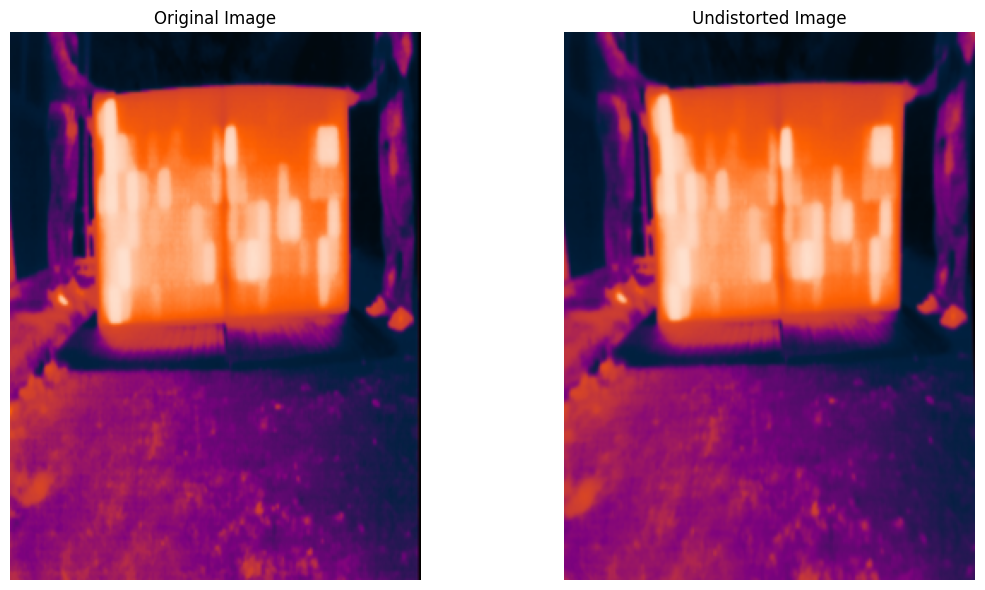

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Load Image
# ==========================================
image_path = "/home/harsh-raj-112/Desktop/Screenshot/Screenshot From 2026-06-09 11-03-49.png"      # Change to your image path
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

h, w = img.shape[:2]

# ==========================================
# Camera Matrix (K)
# ==========================================
K = np.array([
    [332.0018509161,   0.0,            129.2125507213],
    [0.0,            332.8387203425,   149.6005581318],
    [0.0,              0.0,              1.0]
], dtype=np.float64)

# ==========================================
# Distortion Coefficients (D)
# ==========================================
D = np.array([
    [-0.1118981161],
    [ 1.1949862839],
    [-10.6470181155],
    [25.4518617239]
], dtype=np.float64)

# ==========================================
# Estimate New Camera Matrix
# balance:
#   0.0 -> Crop more
#   1.0 -> Keep maximum FOV
# ==========================================
balance = 0.0

new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K,
    D,
    (w, h),
    np.eye(3),
    balance=balance
)

# ==========================================
# Compute Undistortion Maps
# ==========================================
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K,
    D,
    np.eye(3),
    new_K,
    (w, h),
    cv2.CV_16SC2
)

# ==========================================
# Undistort Image
# ==========================================
undistorted = cv2.remap(
    img,
    map1,
    map2,
    interpolation=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT
)

# ==========================================
# Save Result
# ==========================================
cv2.imwrite("Undistorted.png", undistorted)

# ==========================================
# Display Results
# ==========================================
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.title("Undistorted Image")
plt.axis("off")

plt.tight_layout()
plt.show()